In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/models/

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/models


In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image

In [ ]:
class RadiologyDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx, 0]  # Image file path
        label = self.dataframe.iloc[idx, 1]     # 0 or 1 (is_radiology)

        # Load image
        image = Image.open(img_name).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Load the saved model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize the same ResNet18 model as before
model = models.resnet18(pretrained=False)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)  # Binary classification (1 output)

# Load the trained weights
model.load_state_dict(torch.load('radiology_classifier.pth', map_location=device))
model = model.to(device)

# Set the model to evaluation mode
model.eval()

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
<ipython-input-4-ac82fa1542a6>:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [ ]:
from PIL import Image
import torchvision.transforms as transforms

# Define the same image transformation as during training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])  # ImageNet normalization
])

# Function to load and preprocess the image
def preprocess_image(image_path):
    image = Image.open(image_path).convert('RGB')  # Open image and convert to RGB
    image = transform(image)  # Apply transformations
    image = image.unsqueeze(0)  # Add batch dimension (for a single image)
    return image

Saving Screenshot 2024-10-23 at 9.26.02 am.png to Screenshot 2024-10-23 at 9.26.02 am.png


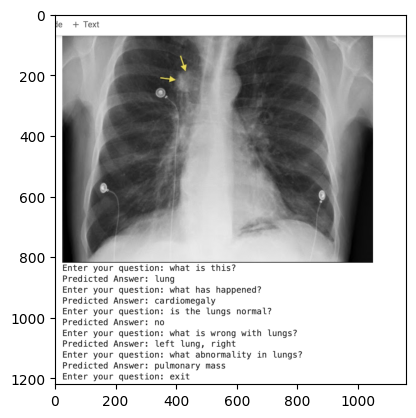

Is a radiological image : 0.9999881982803345
Do you want to continue? (y/n): n


In [ ]:
from google.colab import files
from matplotlib import pyplot as plt
while True:
    uploaded = files.upload()

    img_name = list(uploaded.keys())[0]
    plt.imshow(Image.open(img_name))
    plt.show()

    image = preprocess_image(img_name)

    # Predict on the preprocessed image
    with torch.no_grad():
        image = image.to(device)
        output = model(image)
        prediction = torch.sigmoid(output).item()  # Sigmoid to get the probability


    if prediction >= 0.5:
        print(f"Is a radiological image : {prediction}")
    else:
        print(f"Not a radiological image: {prediction}")
    continue_ = input("Do you want to continue? (y/n): ")
    if continue_.lower() != 'y':
        break